In [ ]:
import pandas as pd
# 读取文件
file1=pd.read_csv(r'musicvideo2.csv', nrows=1500, skiprows=1500, encoding_errors = 'ignore',usecols=[2,5,6,7]) #使用了skiprows之后，需要哪些行只能用数值指定
listx=file1.dropna()  #去掉有缺失的行
listx=listx.values.tolist()
print(len(listx))

In [2]:
import math
math.log(listx[16][3])

12.174721287620278

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import editdistance
import palsgraph
import networkx as nx
from scipy.spatial.distance import squareform

def mismatch(a,b):
    if len(a) == len(b):
        return (np.array(list(a)) != np.array(list(b))).sum()
    return editdistance.eval(a, b)

In [4]:
dist = np.zeros((len(listx), len(listx)))
for i, j in [(i, j) for i in range(len(listx)) for j in range(len(listx)) if i < j]:
    dist[i,j] = dist[j,i] = abs(math.log(listx[i][3],10)-math.log(listx[j][3],10))

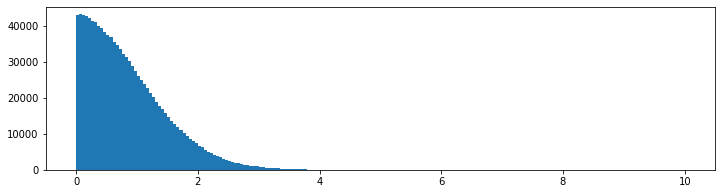

In [5]:
plt.figure(figsize=(12,3))
plt.hist(squareform(dist), range=(0, 10), bins=200)
plt.show()

In [6]:
(squareform(dist)==0).sum(),(squareform(dist)!=0).sum()

(0, 1124250)

In [7]:
threshold = 0.0095
(squareform(dist) < threshold).sum(), (squareform(dist) >= threshold).sum()

(8053, 1116197)

In [8]:
adjmat = np.ones(dist.shape)
adjmat[(dist>= threshold)] = 0

In [9]:
G = palsgraph.make_graph(adjmat,show_singletons=True)
labels={}
for i in range(0,len(listx)):
    labels[i]=listx[i][3]
print(labels)

{0: 2127838, 1: 121378, 2: 1572696, 3: 2697889, 4: 558252, 5: 150363, 6: 1944085, 7: 7987051, 8: 1430545, 9: 496336, 10: 88729, 11: 1475878, 12: 11913715, 13: 4324560, 14: 2941261, 15: 494644, 16: 193827, 17: 1323312, 18: 3286123, 19: 6743056, 20: 254037, 21: 523809, 22: 27723596, 23: 458981, 24: 549272, 25: 35374613, 26: 16121, 27: 23341, 28: 2905153, 29: 2371222, 30: 123835, 31: 1612033, 32: 2896976, 33: 720749, 34: 157137, 35: 2012372, 36: 2313884, 37: 1002848, 38: 239753, 39: 2088933, 40: 5444, 41: 6952956, 42: 13196225, 43: 4599327, 44: 3227378, 45: 502698, 46: 203432, 47: 1393101, 48: 3630119, 49: 7043078, 50: 273943, 51: 584189, 52: 29669903, 53: 478040, 54: 577828, 55: 38902263, 56: 16241, 57: 23764, 58: 3653400, 59: 2544417, 60: 125824, 61: 1649659, 62: 3088180, 63: 3266020, 64: 1359703, 65: 323506, 66: 2332110, 67: 6621, 68: 7990944, 69: 14509303, 70: 4903275, 71: 3494311, 72: 507789, 73: 211157, 74: 1459309, 75: 3957296, 76: 7285995, 77: 293728, 78: 627861, 79: 31725714, 80:

In [10]:
print(G)

Graph with 1470 nodes and 8053 edges


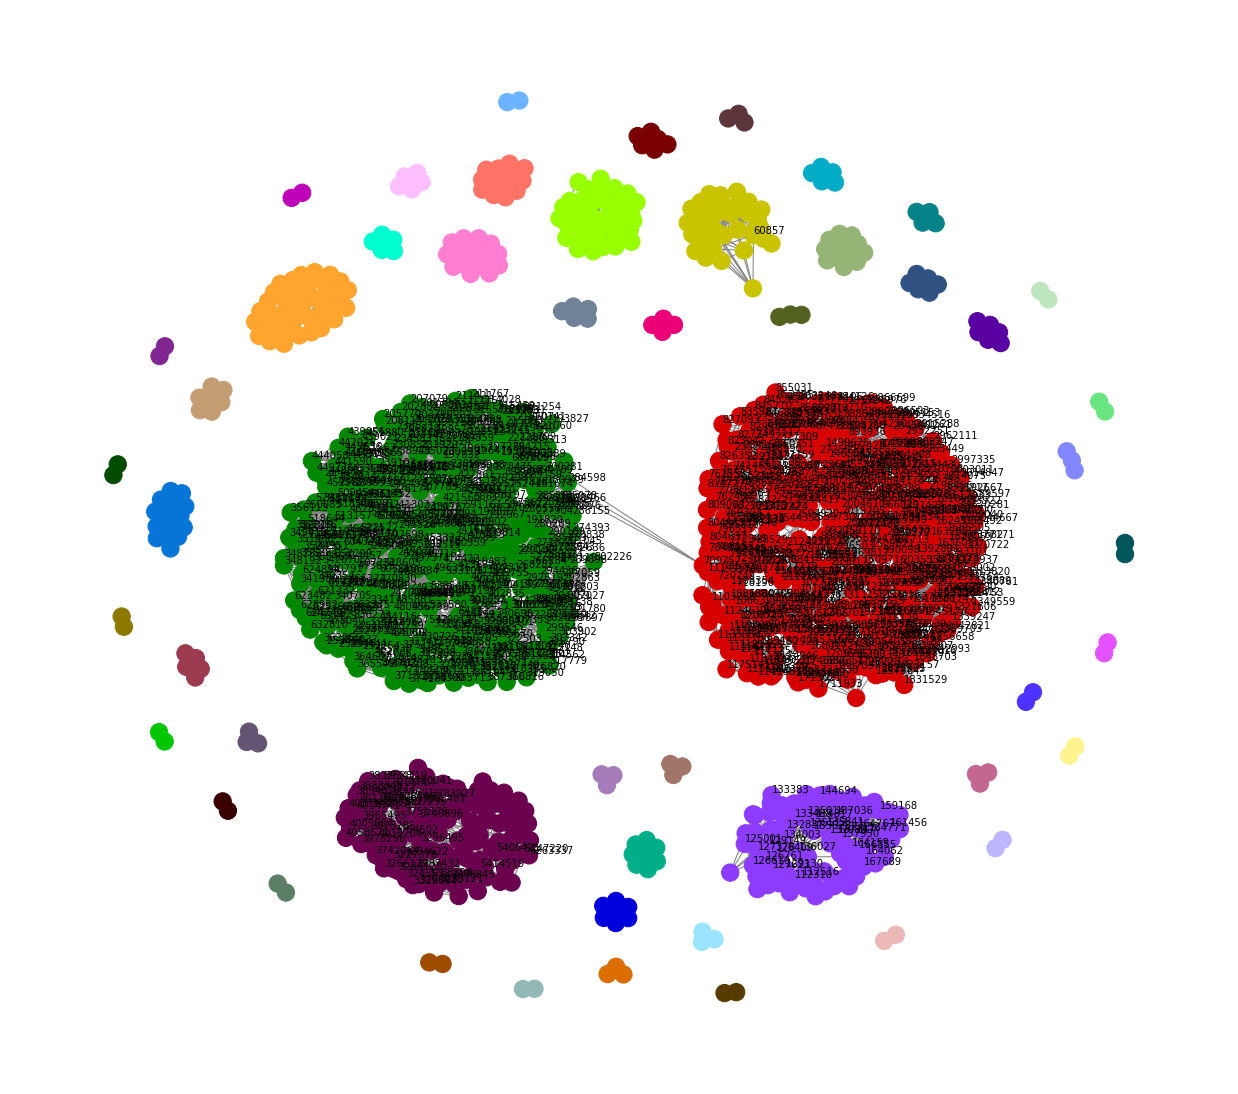

In [11]:
from itertools import islice

comp = nx.algorithms.community.centrality.girvan_newman(G)

max_shown = 1
shown_count = 1
for communities in islice(comp, max_shown): # For each possible set of communities
    pos = palsgraph.getpos(G, communities)
    color_map = palsgraph.gen_colormap(G, communities)
    plt.figure(figsize=(17, 15))
    nx.draw(G, pos=pos, node_color=color_map, edge_color='grey')
    nx.draw_networkx_labels(G, pos,labels={n:lab for n,lab in labels.items() if n in pos and len(list(nx.all_neighbors(G, n))) >9},font_size=10,horizontalalignment='left',verticalalignment='bottom')
    shown_count += 1

In [12]:
#print(type(communities[i]))
''''
threshold = 5000000
Gmax = set() #求平均播放量最大的组
Gall = set() #求平均播放量大于某阈值的视频集合
max_average_counts = 0

for community in communities:
    print(community)
    average_counts = 0
    for c in community:
        average_counts += listx[c][3]
    average_counts /= len(community)
    print(average_counts)
    if average_counts > max_average_counts:
        max_average_counts = average_counts
        Gmax=community
    if average_counts > threshold:
        for c in community:
            Gall.add(c)
        
print(Gall)
num = len(Gall)
print(num)
'''
Gmax = set() #求最大的组
for community in communities:
    if(len(community)>len(Gmax)):
        Gmax=community
print(Gmax)
num = len(Gmax)
print(num)

{4, 9, 15, 16, 20, 21, 23, 24, 38, 45, 46, 50, 51, 53, 54, 65, 72, 73, 77, 78, 80, 81, 93, 100, 101, 105, 106, 108, 110, 117, 119, 120, 125, 126, 134, 135, 138, 140, 142, 143, 145, 146, 152, 153, 162, 164, 166, 168, 171, 172, 179, 187, 190, 193, 201, 202, 209, 213, 217, 220, 221, 229, 230, 241, 245, 249, 250, 259, 266, 271, 275, 276, 285, 287, 288, 289, 291, 292, 297, 298, 307, 310, 311, 313, 325, 326, 327, 328, 332, 342, 351, 353, 355, 356, 357, 360, 370, 379, 380, 382, 385, 386, 392, 395, 398, 400, 405, 406, 408, 410, 411, 419, 423, 426, 429, 431, 435, 437, 439, 440, 444, 452, 453, 456, 459, 460, 464, 467, 468, 471, 478, 483, 492, 493, 496, 497, 500, 502, 506, 515, 516, 519, 520, 521, 526, 528, 531, 539, 540, 543, 545, 548, 550, 554, 555, 562, 563, 564, 567, 569, 570, 572, 575, 579, 580, 587, 592, 596, 598, 599, 604, 615, 617, 618, 619, 620, 621, 623, 628, 630, 635, 636, 637, 642, 644, 648, 649, 666, 667, 674, 675, 676, 678, 685, 689, 693, 698, 703, 705, 707, 712, 713, 720, 722, 724,

In [13]:
def jac(a,b):
    return 1.0 - len(set(a).intersection(set(b))) / len(set(a).union(set(b)))

In [22]:
k = 0
pp=[]
G1 = np.zeros((num, num))    #一个社区的矩阵 标签字母     
for row in Gmax:
    aa = ''
    for i in listx[row][2]:
        if i.isalpha() == True:
            aa= aa + i
    pp.append(aa)
    for last in range(0, k): 
        G1[last][k] =G1[k][last] = jac(pp[last], listx[row][2])
        #print(pp[last])
    k = k + 1    
print(G1)

[[0.         0.33333333 0.33333333 ... 0.54054054 0.48571429 0.30769231]
 [0.33333333 0.         0.42424242 ... 0.48648649 0.47222222 0.4137931 ]
 [0.33333333 0.42424242 0.         ... 0.5952381  0.47368421 0.25      ]
 ...
 [0.54054054 0.48648649 0.5952381  ... 0.         0.57142857 0.58333333]
 [0.48571429 0.47222222 0.47368421 ... 0.57142857 0.         0.45714286]
 [0.30769231 0.4137931  0.25       ... 0.58333333 0.45714286 0.        ]]


In [21]:
k = 0
pp=[]
G2 = np.zeros((num, num))     #一个社区的矩阵 标签的单词
ppp = []
for row in Gmax:          
    aa = ''
    pp = []
    for i in listx[row][2]:
        if i.isalpha() == True:
            aa= aa + i
        elif i != ',':
            if aa:
                pp.append(aa)
                #print(aa)    
            aa = ''
    if aa :
        pp.append(aa)
                    
    ppp.append(pp)    
    for last in range(0, k): 
        #print(last, k,jac(ppp[last], pp))
        G2[last][k] =G2[k][last] =jac(ppp[last], pp)
    k = k + 1   
print(G2)  

[[0.         1.         0.98913043 ... 1.         1.         1.        ]
 [1.         0.         0.98876404 ... 1.         1.         0.95652174]
 [0.98913043 0.98876404 0.         ... 1.         0.9787234  1.        ]
 ...
 [1.         1.         1.         ... 0.         1.         1.        ]
 [1.         1.         0.9787234  ... 1.         0.         1.        ]
 [1.         0.95652174 1.         ... 1.         1.         0.        ]]


In [17]:
'''
k = 0
pp=[]
G3 = np.zeros((num, num))      #一个社区的矩阵 描述的单词
ppp = []
for row in Gmax:           
    aa = ''
    pp = []
    for i in listx[row][4]:
        if i.isalpha() == True:
            aa= aa + i
        elif i != ',':
            if aa:
                pp.append(aa)
            aa = ''
    if aa :
        pp.append(aa)
                    
    ppp.append(pp)    
    for last in range(0, k): 
        G3[last][k] =G3[k][last] =jac(ppp[last], pp)
    k = k + 1  
print(G3)  
'''

"\nk = 0\npp=[]\nG3 = np.zeros((num, num))      #一个社区的矩阵 描述的单词\nppp = []\nfor row in Gmax:           \n    aa = ''\n    pp = []\n    for i in listx[row][4]:\n        if i.isalpha() == True:\n            aa= aa + i\n        elif i != ',':\n            if aa:\n                pp.append(aa)\n            aa = ''\n    if aa :\n        pp.append(aa)\n                    \n    ppp.append(pp)    \n    for last in range(0, k): \n        G3[last][k] =G3[k][last] =jac(ppp[last], pp)\n    k = k + 1  \nprint(G3)  \n"

In [26]:
threshold = 0.25

adjmat1 = np.ones(G1.shape)
adjmat1[(G1 >= threshold)] = 0
G11 = palsgraph.make_graph(adjmat1, show_singletons=True)

adjmat2 = np.ones(G2.shape)
adjmat2[(G2 >= threshold)] = 0
G21 = palsgraph.make_graph(adjmat2, show_singletons=True)

'''
adjmat3 = np.ones(G3.shape)
adjmat3[(G3 >= threshold)] = 0
G31 = palsgraph.make_graph(adjmat3, show_singletons=True)
'''

print(adjmat1)
print(G11)

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
Graph with 387 nodes and 1802 edges


Possible clusters 1 : 

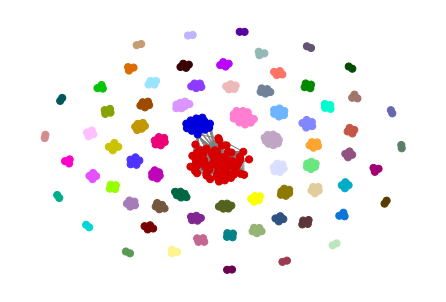

{0: 'lil peep|"come over when you\'re sober"|"save that shit"|"peep"|"mezzy"|"omgimwigs"|"new peep"', 2: 'panic! at the disco|"panic at the disco"|"feels like christmas"|"brendon urie"|"patd"|"dcd2"|"dcd2 records"|"fueled by ramen"|"fbr"', 9: 'camila cabello|"camila"|"cabello"|"never be the same"|"havana"|"crying in the club"|"OMG"|"real friends"', 16: 'keke|"keke palmer"|"Keke Palmer (Musical Artist)"|"music"|"official music video"|"keke palmer music video"|"palmer"|"pregame"|"music video"|"new song"|"2017"|"2017 new song"|"new song video"', 23: 'Linkin Park|"Talking to Myself"|"Other"', 34: 'Dashboard Confessional|"Dashboard"|"Chris Carrabba"|"Chris Caraba"|"Chris Carraba"|"Dashboard Music"|"Dashbaord Band"|"New Dashboard Confessional Song"|"New Song"|"new single"|"We Fight"|"Crooked Shadows"|"We Fight Song"|"official video"|"We fight our way in"|"we fight our way out"|"Fueled By Ramen"|"FBR"|"DC"|"New FBR signing"|"fueled by"|"dashboard signs with FBR"|"New Dashboard Record"|"New Da

Possible clusters 2 : 

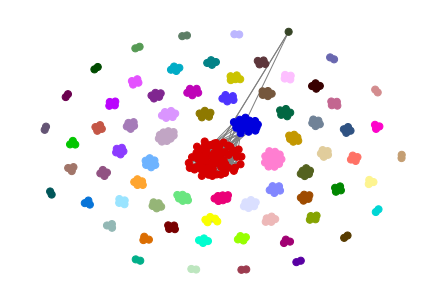

{0: 'lil peep|"come over when you\'re sober"|"save that shit"|"peep"|"mezzy"|"omgimwigs"|"new peep"', 2: 'panic! at the disco|"panic at the disco"|"feels like christmas"|"brendon urie"|"patd"|"dcd2"|"dcd2 records"|"fueled by ramen"|"fbr"', 9: 'camila cabello|"camila"|"cabello"|"never be the same"|"havana"|"crying in the club"|"OMG"|"real friends"', 16: 'keke|"keke palmer"|"Keke Palmer (Musical Artist)"|"music"|"official music video"|"keke palmer music video"|"palmer"|"pregame"|"music video"|"new song"|"2017"|"2017 new song"|"new song video"', 23: 'Linkin Park|"Talking to Myself"|"Other"', 34: 'Dashboard Confessional|"Dashboard"|"Chris Carrabba"|"Chris Caraba"|"Chris Carraba"|"Dashboard Music"|"Dashbaord Band"|"New Dashboard Confessional Song"|"New Song"|"new single"|"We Fight"|"Crooked Shadows"|"We Fight Song"|"official video"|"We fight our way in"|"we fight our way out"|"Fueled By Ramen"|"FBR"|"DC"|"New FBR signing"|"fueled by"|"dashboard signs with FBR"|"New Dashboard Record"|"New Da

Possible clusters 3 : 

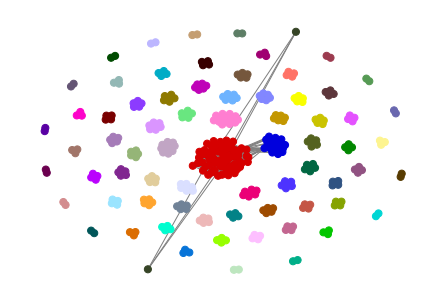

{0: 'lil peep|"come over when you\'re sober"|"save that shit"|"peep"|"mezzy"|"omgimwigs"|"new peep"', 2: 'panic! at the disco|"panic at the disco"|"feels like christmas"|"brendon urie"|"patd"|"dcd2"|"dcd2 records"|"fueled by ramen"|"fbr"', 9: 'camila cabello|"camila"|"cabello"|"never be the same"|"havana"|"crying in the club"|"OMG"|"real friends"', 16: 'keke|"keke palmer"|"Keke Palmer (Musical Artist)"|"music"|"official music video"|"keke palmer music video"|"palmer"|"pregame"|"music video"|"new song"|"2017"|"2017 new song"|"new song video"', 23: 'Linkin Park|"Talking to Myself"|"Other"', 34: 'Dashboard Confessional|"Dashboard"|"Chris Carrabba"|"Chris Caraba"|"Chris Carraba"|"Dashboard Music"|"Dashbaord Band"|"New Dashboard Confessional Song"|"New Song"|"new single"|"We Fight"|"Crooked Shadows"|"We Fight Song"|"official video"|"We fight our way in"|"we fight our way out"|"Fueled By Ramen"|"FBR"|"DC"|"New FBR signing"|"fueled by"|"dashboard signs with FBR"|"New Dashboard Record"|"New Da

In [17]:
import itertools

comp = nx.algorithms.community.centrality.girvan_newman(G11)
#comp = nx.algorithms.community.centrality.girvan_newman(G21)
#comp = nx.algorithms.community.centrality.girvan_newman(G31)
max_shown = 3
shown_count = 1
community_dict = {}
community_num = 0
tags_dict={}

for communities in itertools.islice(comp, max_shown):
    for community in communities:
        #print(community)
        for character in community:
            community_dict[character] = community_num
            tags_dict[character] = listx[character][2]
        community_num += 1
    nx.set_node_attributes(G11, community_dict, 'community')
    nx.set_node_attributes(G11, tags_dict, 'tags')
    print("Possible clusters", shown_count, ": ", end='')
    #print(communities)
    
    pos = palsgraph.getpos(G11, communities)
    
    color_map = palsgraph.gen_colormap(G11, communities)

    shown_count += 1

    nx.draw(G11, pos=pos,
            node_color=color_map,
            edge_color='grey',
            font_size=8,
            font_color='darkslategray',
            node_size=50)
            #labels={n:lab for n,lab in tags_dict.items() if n in pos and len(list(nx.all_neighbors(G11, n))) >9})
    plt.show()
    #print(community_dict)
    print(tags_dict)
    print(communities[0])
    print(type(communities))
    nx.write_gexf(G11, "0.gexf")

[(27, 1), (29, 1), (6, 2), (8, 2), (9, 2), (13, 2), (16, 2), (20, 2), (24, 2), (30, 2), (33, 2), (36, 2), (41, 2), (48, 2), (60, 2), (63, 2), (70, 2), (71, 2), (12, 3), (18, 3), (19, 3), (31, 3), (42, 3), (43, 3), (55, 3), (69, 3), (2, 4), (3, 4), (4, 4), (11, 4), (17, 4), (22, 4), (25, 4), (38, 4), (39, 4), (40, 4), (44, 4), (45, 4), (46, 4), (49, 4), (54, 4), (57, 4), (67, 4), (68, 4), (1, 5), (7, 5), (14, 5), (23, 5), (28, 5), (32, 5), (34, 5), (35, 5), (51, 5), (58, 5), (62, 5), (65, 5), (15, 6), (21, 6), (37, 6), (47, 6), (50, 6), (53, 6), (59, 6), (64, 6), (26, 7), (52, 7), (61, 7), (66, 7), (56, 11), (5, 15), (10, 18), (0, 77)]


C:\Users\10462\AppData\Local\Temp\ipykernel_14168\2096218713.py:21: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning dissapear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  pic=imageio.imread("Youtube.png")


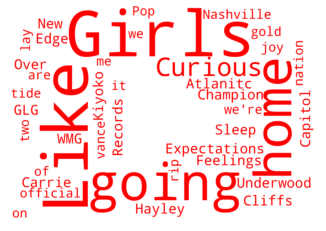

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import imageio

Gmax = set() #求最大的组
len_dict = {}

for i in range(0,len(communities)):
    len_dict[i] = len(communities[i])
sorted_len_dict = sorted(len_dict.items(), key = lambda kv:(kv[1], kv[0]))
print(sorted_len_dict)

count = 5 #画多少个图
i = len(sorted_len_dict) - 1
while i >= len(sorted_len_dict) - 3 - count:
    s = ""
    for j in communities[i]:
        #print(listx[j][2])
        s += listx[j][2]
    #print(s)
    pic=imageio.imread("Youtube.png")
    wordcloud=WordCloud(width=600,height=400,max_words=400,stopwords={'music','the','video'},background_color="white",mask=pic,scale=2,
                        color_func=lambda *args, **kwargs: "red")
    wordcloud.generate(s)
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis("off")
    wordcloud.to_file("WordCloud.png")
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.savefig("0.png")
    i -= 1

In [27]:
# 以下的没用

max_tags_dict = {}

for c in Gmax:
    tag = ''
    for i in listx[c][2]:
        if i.isalpha() or i == ' ': #去掉非字母非空格
            tag = tag + i
        else:
            if tag:
                print(tag)
                if tag in max_tags_dict:
                    max_tags_dict[tag] += 1
                else:
                    max_tags_dict[tag] = 1
            tag = ''
    #print(max_tags_dict)
sorted_max_tags_dict = sorted(max_tags_dict.items(), key = lambda kv:(kv[1], kv[0])) #按key排列,得到元组的列表
print(sorted_max_tags_dict)

x=[]
y=[]
for i in sorted_max_tags_dict:
    x.append(i[0])
    y.append(i[1])
print(x)
print(y)

spotify
free
music
ed sheeran
ed
sheeran
teddy
teddys photos
gingerbread
cookies
cute
funny
comedy
holidays
happy holidays
christmas
camila cabello
camila
cabello
never be the same
havana
crying in the club
OMG
real friends
album
review
music
reviews
indie
underground
new
latest
lyrics
full song
listen
track
concert
live
performance
the needle drop
anthony fantano
vlog
alex cameron
algiers
ariel pink
brockhampton
cardi b
bodak yellow
charli xcx
boys
father john misty
fleet foxes
feist
big krit
iglooghost
injury reserve
jay
z
story of oj
kendrick lamar
humble
kirin j callinan
lil pump
gucci gang
lorde
migos
n
e
r
d
paramore
post malone
playboi carti
magnolia
poppy
rock
pop
rap
keke
keke palmer
Keke Palmer 
Musical Artist
music
official music video
keke palmer music video
palmer
pregame
music video
new song
 new song
new song video
Nick
Jonas
Home
Island
Records
Soundtrack
music
official
music video
Linkin Park
Talking to Myself
Other
Sugarland
Still
The
Same
Big
Machine
Country
Chloe x 

C:\Users\10462\miniconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 38450 (\N{CJK UNIFIED IDEOGRAPH-9632}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10462\miniconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 24392 (\N{CJK UNIFIED IDEOGRAPH-5F48}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10462\miniconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 23569 (\N{CJK UNIFIED IDEOGRAPH-5C11}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10462\miniconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\10462\miniconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 22296 (\N{CJK UNIFIED IDEOGRAPH-5718}) missing from current font.
  fig.canvas.print_figure(b

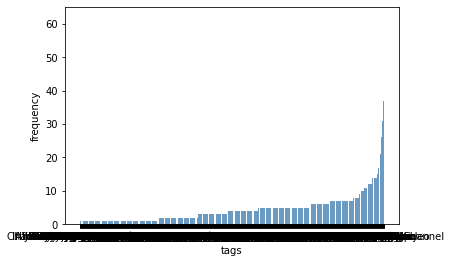

In [28]:
import matplotlib.pyplot as plt
plt.bar(range(len(y)), y ,align = 'center',color='steelblue', alpha = 0.8)
plt.ylabel('frequency')
plt.xlabel('tags')
plt.xticks(range(len(x)), x)
plt.show()


Anthem Films
Chad Kroeger
Chess Club
Christmas
Columbia
Daniel Adair
Documental
Documentary
Feed The Machine
Finally It
Foster
Hanson
How You Remind Me
I
Indie
Interscope
Kevin Slack
Let You Down
Magnetic
Me
Mike Kroeger
Musica Sin Fronteras
MØ
Música Sin Fronteras
NF
Next
Nickelback
Odisea
Odisea The Album
Ozuna
People
Phillip
Phillips
RCA Victor
Reggaeton
Rock
Rockstar
Ryan Peake
Sit
Snowed In
The
The Betrayal
The Betrayal Act III
Vertical
Video
When I Was Young
YouTube Documentary
album
andy
bach improv
chopin
chopin improv
classical composers imitation
classical music
classical music funny
classical music improv
clears
debussy improv
good
grammer
hip
hop
improvisation
improvise classical music
m sorry that I let you down
mu
music
music funny
music imitation
music satire
music video
nahre sol
nahre sol music
new
nf official
nfrealmusic
official video
parts
perception
piano improv
piano improviser
pop
rap
s Christmas
smoke
songwriter
the
to
whole tone scale
Alternative
Hopeless Recor

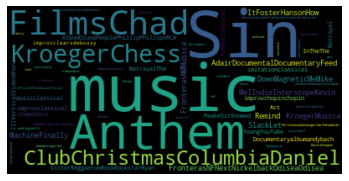

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

s = ""
for i in x:
    s += i
    print(i)
print(s)
wordcloud = WordCloud().generate(s)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.savefig('0.png')